# Exploration des données dans le dossier bronze/ dans S3

In [45]:
import yaml
import boto3
import pandas as pd
import pyarrow
import io
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


## To-do list
1. Structure & volume
  - Schéma de chaque fichier (colonnes, types inférés)                                    
  - Nombre de lignes par fichier                                                                    
                                                                                          
  2. Clés & identifiants                                                                
  - Taux de correspondance avec le référentiel ZdC                                        
                                                                                          
  3. Qualité des données                                                                  
  - Taux de nulls par colonne                                                             
  - Valeurs aberrantes (ex : 0 validations, dates hors périmètre)                         
  - Doublons                                                                            
                                                          
  4. Couverture temporelle
  - Toutes les années 2015-2024 sont-elles présentes ?                                    
  - Continuité des données (pas de trou sur une période)                                  
  
  5. Joinabilité                                                                          
  - Les ID_REFA_LDA des validations matchent-ils bien le référentiel accessibilité ?    
  - Stations présentes dans un fichier mais absentes de l'autre   

## **rappel** 

Cette étape de data exploration survient après l'ingestion réalisée dans S3. Les fichiers sources ont été exportés en .parquet dans S3 dans le dossier bronze/. Trois types de fichiers :
- `NB_FER` : séparés dans des dossiers par année  avec deux fichiers chacun (un par semestre)
- `accessibilité` : un seul fichier .parquet à la racine de bronze/
- `references` : un seul fichier .parquet à la racine de bronze/


Il y a logiquement : 

- NB_FER : (2024-2016)x2 = 16 fichiers -> on n'en garde que 3 (de l'année 2024)
- accessibilité = 1 fichier
- références = 1 fichier

--> 5 fichiers

## 0 - On passe nos trois fichiers dans S3 en DataFrame pour exploration : 
 - NB_FER_2024 (données de S1 + T3 + T4 de 2024)
 - ACCESSIBILITE
 - REFERENCE
 ---


### CONFIG CLIENT

In [2]:
s3_client = boto3.client('s3')

In [3]:
file = open("../../config/config.yaml")
yaml_file = yaml.safe_load(file)
file.close()

In [4]:
bucket = yaml_file['S3']['bucket']
prefix = yaml_file['S3']['chemins_dossiers']['bronze']

In [5]:
list = s3_client.list_objects_v2(
Bucket = bucket,
Prefix = prefix
)

In [6]:
list.keys()

dict_keys(['ResponseMetadata', 'IsTruncated', 'Contents', 'Name', 'Prefix', 'MaxKeys', 'EncodingType', 'KeyCount'])

In [7]:
list_objects = list['Contents']

### NB_FER_2024

-> Pour notre analyse, on ne garde que les fichiers de l'année 2024

In [8]:
scope_objects = [i['Key'] for i in list_objects if '2024'in i['Key']]

In [9]:
dfs = []                                               

for i in scope_objects:                                
    obj = s3_client.get_object(Bucket=bucket, Key=i)
    df = pd.read_parquet(io.BytesIO(obj['Body'].read()))
    dfs.append(df)

In [10]:
semestre1_2024 = dfs[0]
trimestre3_2024 = dfs[1]
trimestre4_2024 = dfs[2]

In [11]:
NB_FER_2024 = pd.concat([
    semestre1_2024,
    trimestre3_2024,
    trimestre4_2024
    ],
    ignore_index= True
)

### ACCESSIBILITE

In [12]:
scope_object_access = [i['Key'] for i in list_objects if i['Key']=="bronze/accessibilite_en_gare.parquet"][0]

In [120]:
obj = s3_client.get_object(Bucket=bucket, Key=scope_object_access)
ACCESSIBILITE= pd.read_parquet(io.BytesIO(obj['Body'].read()))

### REFERENCES

In [14]:
scope_object_references = [i['Key'] for i in list_objects if i['Key']=="bronze/references.parquet"][0]

In [15]:
obj = s3_client.get_object(Bucket=bucket, Key=scope_object_references)
REFERENCES= pd.read_parquet(io.BytesIO(obj['Body'].read()))

## 1. Structure & volume
  - Schéma de chaque fichier (colonnes, types inférés)                                    
  - Nombre de lignes par fichier
---                                             

In [16]:
NB_FER_2024.dtypes

JOUR                object
CODE_STIF_TRNS       int64
CODE_STIF_RES       object
CODE_STIF_ARRET     object
LIBELLE_ARRET       object
ID_ZDC             float64
CATEGORIE_TITRE     object
NB_VALD             object
dtype: object

In [17]:
ACCESSIBILITE.dtypes

stop_point_id               object
accessibility_level_id       int64
accessibility_level_name    object
commentaire                 object
stop_name                   object
stop_point_geopoint         object
dtype: object

In [18]:
REFERENCES.dtypes

zdaid              object
zdaversion         object
zdacreated         object
zdachanged         object
zdaname            object
zdaxepsg2154        int64
zdayepsg2154        int64
zdcid              object
zdapostalregion    object
zdatown            object
zdatype            object
dtype: object

- `NB_VALD` est de type `object` alors qu'il représente un nombre de validations -> à convertir en numérique en Silver(attention aux valeurs non convertibles)
- `ID_ZDC` est en `float64` dans NB_FER_2024 et `zdcid` est en `object` dans REFERENCES —> les types doivent être harmonisés avant la jointure
- La jointure se fait en deux étapes via la table pivot REFERENCES : `NB_FER_2024.ID_ZDC → REFERENCES.zdcid → REFERENCES zdaid → ACCESSIBILITE.stop_point_id`
- NB_FER_2024 est la concaténation de 3 fichiers (S1, T3, T4) —> vérifier l'absence de doublons après concat

In [19]:
NB_FER_2024.shape

(1797296, 8)

In [20]:
ACCESSIBILITE.shape

(459, 6)

In [21]:
REFERENCES.shape

(18045, 11)

- 1,8M de lignes pour NB_FER_2024 — c'est du volume conséquent, confirme l'intérêt d'Athena pour la Silver
- 459 lignes pour ACCESSIBILITE — c'est peu, ce sont les points d'arrêt (ZdA), pas les  stations (ZdC)                                                                          
- 18 045 lignes pour REFERENCES — la table pivot ZdA ↔ ZdC

## 3. Qualité des données                                                                  
  - Taux de nulls par colonne                                                             
  - Valeurs aberrantes (ex : 0 validations, dates hors périmètre)                         
  - Doublons 

In [22]:
validations_NA = pd.to_numeric(NB_FER_2024[NB_FER_2024['ID_ZDC'].isna()]['NB_VALD'], errors='coerce').sum() #nombre de validations qui n'appartiennent à aucune ZdC : 2,3M.
validations_total = pd.to_numeric(NB_FER_2024['NB_VALD'], errors='coerce').sum() #nombre de validations au total

ratio_NA_validations = validations_NA/validations_total * 100
print(ratio_NA_validations) #est négligeable, conclusion = supprimer les lignes

0.14600720236127307


In [23]:
ACCESSIBILITE.isnull().sum() #pas d'incidence à noter

stop_point_id                 0
accessibility_level_id        0
accessibility_level_name      0
commentaire                 442
stop_name                     0
stop_point_geopoint           0
dtype: int64

In [24]:
REFERENCES.isnull().sum()

zdaid              0
zdaversion         0
zdacreated         0
zdachanged         0
zdaname            0
zdaxepsg2154       0
zdayepsg2154       0
zdcid              0
zdapostalregion    0
zdatown            0
zdatype            1
dtype: int64

In [25]:
 REFERENCES[REFERENCES['zdatype'].isna()] # aucune incidence, le reste des données est complet.

,zdaid,zdaversion,zdacreated,zdachanged,zdaname,zdaxepsg2154,zdayepsg2154,zdcid,zdapostalregion,zdatown,zdatype
8519,49200,1326704-1326705,2014-12-28T23:00:00+00:00,2026-03-05T08:57:22+00:00,Château - Campus,622178,6861378,64270,78615,Thiverval-Grignon,None


### On teste l'unicité de colonnes cibles

on a que des valeurs uniques pour chaque arrêt, identifiable grâce à la colonne 'CODE_STIF_ARRET'.

In [26]:
NB_FER_2024.value_counts(ascending=False, subset=['JOUR','ID_ZDC','CODE_STIF_ARRET','CATEGORIE_TITRE','NB_VALD'])

JOUR        ID_ZDC    CODE_STIF_ARRET  CATEGORIE_TITRE               NB_VALD
01/01/2024  59403.0   18.0             Contrat Solidarité Transport  4          1
2024-12-03  72648.0   77               Forfait Navigo                1292       1
            72787.0   1204             Amethyste                     47         1
            72652.0   242              NON DEFINI                    64         1
                                       Imagine R                     1413       1
                                                                               ..
14/07/24    71799.0   684              Autres titres                 543        1
                                       Amethyste                     286        1
            71795.0   774              NON DEFINI                    33         1
                                       Imagine R                     424        1
31/08/24    999999.0  ND               NON DEFINI                    12         1
Name: count, Length: 

In [27]:
NB_FER_2024['NB_VALD'] = pd.to_numeric(NB_FER_2024['NB_VALD'], errors='coerce')


## Test valeurs aberrantes, check de la distribution

In [28]:
NB_FER_2024['NB_VALD'].isna().sum()

103085

In [29]:
 NB_FER_2024['NB_VALD'].dtype

dtype('float64')

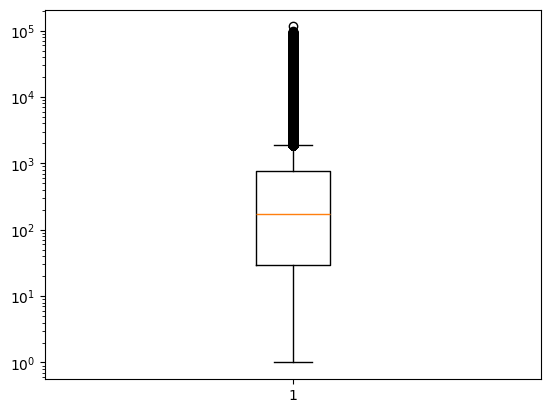

In [36]:
plt.boxplot(NB_FER_2024['NB_VALD'].dropna())
plt.yscale('log')
plt.show()

In [37]:
print(NB_FER_2024['NB_VALD'].describe().apply(lambda val: f"{val:,.0f}"))  

count    1,694,211
mean           910
std          2,576
min              1
25%             29
50%            174
75%            775
max        115,597
Name: NB_VALD, dtype: object


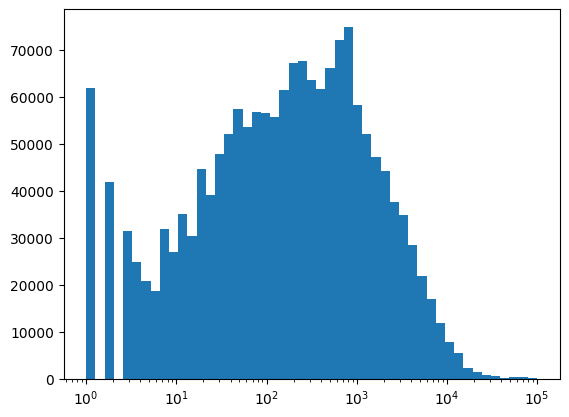

In [50]:
plt.hist(
        NB_FER_2024['NB_VALD'].dropna(),
        bins = np.logspace(0,5,50), #0 pour valeur de départ à 1, jusqu'à 10^5, 5O bins.
        )
plt.xscale('log')

## On fait les mêmes vérifications pour la table REFEERENCES

In [ ]:
print('Doublons zdaid :', REFERENCES['zdaid'].duplicated().sum())

Doublons zdaid : 0


ZdC uniques dans REFERENCES : 15499

Distribution du nb de ZdA par ZdC :
count    15499.000000
mean         1.164269
std          0.503554
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         12.000000
Name: zdaid, dtype: float64
ID_ZDC dans NB_FER non trouvés dans REFERENCES : 18
Soit 2.4% des ZdC de NB_FER


### l'objectif est de vérifier qu'il n'y a pas deux versions différentes d'une même zda

In [69]:
REFERENCES.groupby(['zdaname','zdatown'])['zdaid'].nunique().sort_values(ascending= False)
# Il y a des stations qui ont le même nom de ville mais...

zdaname                                 zdatown            
Parc Pierre Lagravère                   Colombes               3
Château Landon                          Paris 10e              3
Basilique de Saint-Denis                Saint-Denis            3
Porte de Vanves                         Paris 14e              3
Porte de Charenton                      Paris 12e              3
                                                              ..
Gare de Houdan                          Houdan                 1
Gare de Houilles - Carrières-sur-Seine  Houilles               1
Gare de Héricy                          Héricy                 1
Gare de Isles - Armentières - Congis    Isles-les-Meldeuses    1
Îles Glénan                             Maurepas               1
Name: zdaid, Length: 17582, dtype: int64

In [70]:
REFERENCES.loc[REFERENCES['zdaname'] == "Parc Pierre Lagravère"]
# ... on voit bien qu'il s'agit de stations distinctes

,zdaid,zdaversion,zdacreated,zdachanged,zdaname,zdaxepsg2154,zdayepsg2154,zdcid,zdapostalregion,zdatown,zdatype
1375,44678,1717560-1017522,2014-12-28T23:00:00+00:00,2026-01-26T14:22:51+00:00,Parc Pierre Lagravère,643181,6868901,70975,92025,Colombes,onstreetTram
2034,491368,1564824-1566444,2024-04-03T17:08:55+00:00,2024-04-15T14:07:09+00:00,Parc Pierre Lagravère,644470,6870303,491418,92025,Colombes,onstreetBus
10295,462881,1017514-1017522,2019-01-09T23:00:00+00:00,2024-07-04T09:48:14+00:00,Parc Pierre Lagravère,643187,6868926,70975,92025,Colombes,onstreetBus


### On vérifie qu'il n'y a pas de valeurs nulles

In [71]:
REFERENCES.isna().sum()

zdaid              0
zdaversion         0
zdacreated         0
zdachanged         0
zdaname            0
zdaxepsg2154       0
zdayepsg2154       0
zdcid              0
zdapostalregion    0
zdatown            0
zdatype            1
dtype: int64

In [73]:
REFERENCES[REFERENCES['zdatype'].isna()] # ce n'est pas grave

,zdaid,zdaversion,zdacreated,zdachanged,zdaname,zdaxepsg2154,zdayepsg2154,zdcid,zdapostalregion,zdatown,zdatype
8519,49200,1326704-1326705,2014-12-28T23:00:00+00:00,2026-03-05T08:57:22+00:00,Château - Campus,622178,6861378,64270,78615,Thiverval-Grignon,None


## On teste l'existance de jointure pour chaque clef dans NB_FER_2024 avec REFERENCES

 ZdC (Gare de Lyon)                                                                     
  ├── ZdA (quai RER A)                                                                   
  ├── ZdA (quai RER D)                                                                   
  ├── ZdA (quai Transilien)                                                              
  └── ZdA (accès bus) 


Donc on a la relation et cardinalité suivante : 

`ZdC` 1-* `ZdA` (one to many)
on doit vérifier qu'il existe bien un **identifiant unique de ZdC pour chaque ZdA**

___

### On commence par vérifier l'exitence de l'identifiant de ZdC de la table NB_FER_2024 dans REFERENCES

On énumère combien d'identifiants n'ont pas d'id dans la table références grace à la condition contraire à `isin()` avec le `~`

In [93]:
NB_FER_2024[~NB_FER_2024['ID_ZDC'].astype('Int64').isin(pd.to_numeric(REFERENCES['zdcid']))].shape[0]
#48366 à supprimer

48366

### On vérifie la cardinalité

In [ ]:
REFERENCES.groupby('zdaid')['zdcid'].nunique().eq(1).all()
""""
1. groupby('zdaid') — regroupe les lignes par ZdA                                      
2. ['zdcid'].nunique() — pour chaque ZdA, compte le nombre de zdcid distincts →        
retourne une Series avec un entier par ZdA                                             
3. .eq(1).all() — vérifie que toutes ces valeurs sont égales à 1 → retourne True ou    
False   
"""

True

## Test jointure REFERENCES et ACCESSIBILITE + qualité

In [102]:
print('Doublons stop_point_id :', ACCESSIBILITE['stop_point_id'].duplicated().sum()) 

Doublons stop_point_id : 0


In [121]:
ACCESSIBILITE['stop_point_id']

0      stop_point:IDFM:monomodalStopPlace:43069
1      stop_point:IDFM:monomodalStopPlace:46395
2      stop_point:IDFM:monomodalStopPlace:43071
3      stop_point:IDFM:monomodalStopPlace:45437
4      stop_point:IDFM:monomodalStopPlace:47119
                         ...                   
454    stop_point:IDFM:monomodalStopPlace:43211
455    stop_point:IDFM:monomodalStopPlace:46304
456    stop_point:IDFM:monomodalStopPlace:46307
457    stop_point:IDFM:monomodalStopPlace:46725
458    stop_point:IDFM:monomodalStopPlace:47136
Name: stop_point_id, Length: 459, dtype: object

Ne pas oublier de récupérer la partie 

In [125]:
stop_ids = ACCESSIBILITE['stop_point_id'].str.split(':').str[-1]

In [126]:
non_couverts_acc = ACCESSIBILITE[~stop_ids.isin(REFERENCES['zdaid'])].shape[0]         
total_acc = ACCESSIBILITE.shape[0]                                                     
print(f'Stops ACCESSIBILITE sans correspondant dans REFERENCES : {non_couverts_acc}({non_couverts_acc/total_acc*100:.1f}%)') 

Stops ACCESSIBILITE sans correspondant dans REFERENCES : 0(0.0%)
